### Model Evaluation and Business Impact Analysis

#### OBJECTIVE:
Evaluate the baseline Logistic Regression model from a business perspective
and calculate the financial impact of deploying the fraud detection system.

#### KEY QUESTIONS ANSWERED:
1. How well does the model identify fraud?
2. What is the cost-benefit of different decision thresholds?
3. Which claims should be prioritized for manual review?
4. What is the expected ROI of deploying this model?

#### BUSINESS CONTEXT:
- Manual claim review costs approximately $35 per claim
- Average fraudulent claim: ~$15,000
- False positives annoy providers and delay legitimate payments
- False negatives allow fraud to slip through

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_fscore_support, roc_curve, precision_recall_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("MODEL EVALUATION AND BUSINESS IMPACT ANALYSIS")
print("="*80)


MODEL EVALUATION AND BUSINESS IMPACT ANALYSIS


In [2]:

# ==============================================================================
# PART 1: LOAD MODEL AND TEST DATA
# ==============================================================================

print("\nPART 1: Loading model and test data...")
print("-" * 80)

# Load the trained baseline model
PROJECT_ROOT = Path().resolve().parents[1]
model = joblib.load(PROJECT_ROOT/'models'/'fraud'/'baseline_logistic_regression.pkl')
scaler = joblib.load(PROJECT_ROOT/'models'/'fraud'/'feature_scaler.pkl')
feature_list = joblib.load(PROJECT_ROOT/'models'/'fraud'/'feature_list.pkl')

print("Model loaded: Logistic Regression")
print(f"Features: {len(feature_list)}")

# Load test data
# We need to recreate the train-test split to get the same test set
from sklearn.model_selection import train_test_split

inpatient = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'inpatient_labeled.csv')
X = inpatient[feature_list].fillna(inpatient[feature_list].median())
y = inpatient['is_fraud_80']

# Use same random_state to get identical split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale test features
X_test_scaled = scaler.transform(X_test)

# Get predictions
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print(f"\nTest set: {len(y_test):,} claims")
print(f"  Actual fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"  Predicted fraud: {y_pred.sum():,} ({y_pred.mean()*100:.2f}%)")


PART 1: Loading model and test data...
--------------------------------------------------------------------------------
Model loaded: Logistic Regression
Features: 40

Test set: 13,355 claims
  Actual fraud: 46 (0.34%)
  Predicted fraud: 132 (0.99%)



PART 2: Optimizing decision threshold...
--------------------------------------------------------------------------------

Optimal threshold: 0.90
  F1-Score: 0.5594
  Precision: 0.4124
  Recall: 0.8696


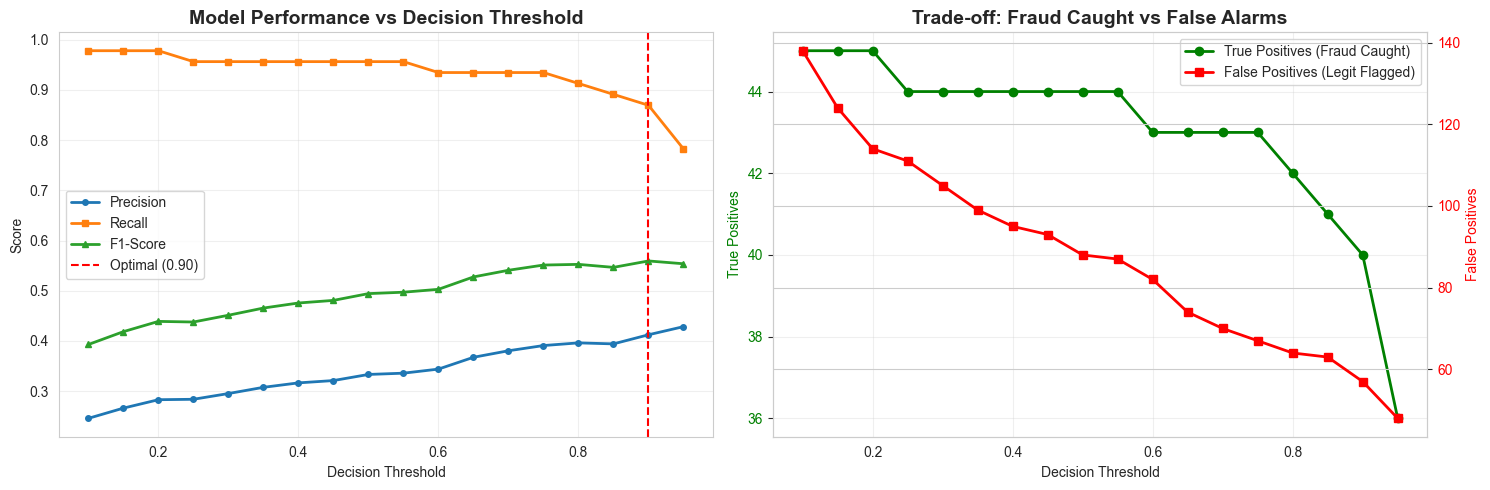


Threshold analysis saved to: ../docs/threshold_optimization.png


In [4]:

# ==============================================================================
# PART 2: THRESHOLD OPTIMIZATION
# ==============================================================================

print("\nPART 2: Optimizing decision threshold...")
print("-" * 80)

# Default threshold is 0.5, but we can optimize for business needs
# Different thresholds balance precision (accuracy of flags) vs recall (catching fraud)

# Calculate metrics at different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_threshold, average='binary', zero_division=0
    )
    
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    })

results_df = pd.DataFrame(results)

# Find optimal threshold
# We'll optimize for F1-score (balance of precision and recall)
optimal_idx = results_df['f1_score'].idxmax()
optimal_threshold = results_df.loc[optimal_idx, 'threshold']

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"  F1-Score: {results_df.loc[optimal_idx, 'f1_score']:.4f}")
print(f"  Precision: {results_df.loc[optimal_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[optimal_idx, 'recall']:.4f}")

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Precision, Recall, F1 vs Threshold
axes[0].plot(results_df['threshold'], results_df['precision'], 
             label='Precision', linewidth=2, marker='o', markersize=4)
axes[0].plot(results_df['threshold'], results_df['recall'], 
             label='Recall', linewidth=2, marker='s', markersize=4)
axes[0].plot(results_df['threshold'], results_df['f1_score'], 
             label='F1-Score', linewidth=2, marker='^', markersize=4)
axes[0].axvline(optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal ({optimal_threshold:.2f})')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance vs Decision Threshold', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: True Positives and False Positives vs Threshold
ax2 = axes[1]
ax2.plot(results_df['threshold'], results_df['tp'], 
         label='True Positives (Fraud Caught)', linewidth=2, color='green', marker='o')
ax2_twin = ax2.twinx()
ax2_twin.plot(results_df['threshold'], results_df['fp'], 
              label='False Positives (Legit Flagged)', linewidth=2, color='red', marker='s')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('True Positives', color='green')
ax2_twin.set_ylabel('False Positives', color='red')
ax2.set_title('Trade-off: Fraud Caught vs False Alarms', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.grid(alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThreshold analysis saved to: ../docs/threshold_optimization.png")


PART 3: Calculating business impact...
--------------------------------------------------------------------------------

Business parameters:
  Manual review cost: $35
  Average fraud claim: $53,746.72
  Average legit claim: $9,421.62

Threshold: 0.50
  Fraud caught: 44 claims ($2,364,856 prevented)
  Fraud missed: 2 claims ($107,493 loss)
  False alarms: 88 claims
  Review cost: $4,620
  Net benefit: $2,360,236
  ROI: 51087.4%

Threshold: 0.90
  Fraud caught: 40 claims ($2,149,869 prevented)
  Fraud missed: 6 claims ($322,480 loss)
  False alarms: 57 claims
  Review cost: $3,395
  Net benefit: $2,146,474
  ROI: 63224.6%

Threshold: 0.70
  Fraud caught: 43 claims ($2,311,109 prevented)
  Fraud missed: 3 claims ($161,240 loss)
  False alarms: 70 claims
  Review cost: $3,955
  Net benefit: $2,307,154
  ROI: 58335.1%

Threshold: 0.80
  Fraud caught: 42 claims ($2,257,362 prevented)
  Fraud missed: 4 claims ($214,987 loss)
  False alarms: 64 claims
  Review cost: $3,710
  Net benefit: $2,

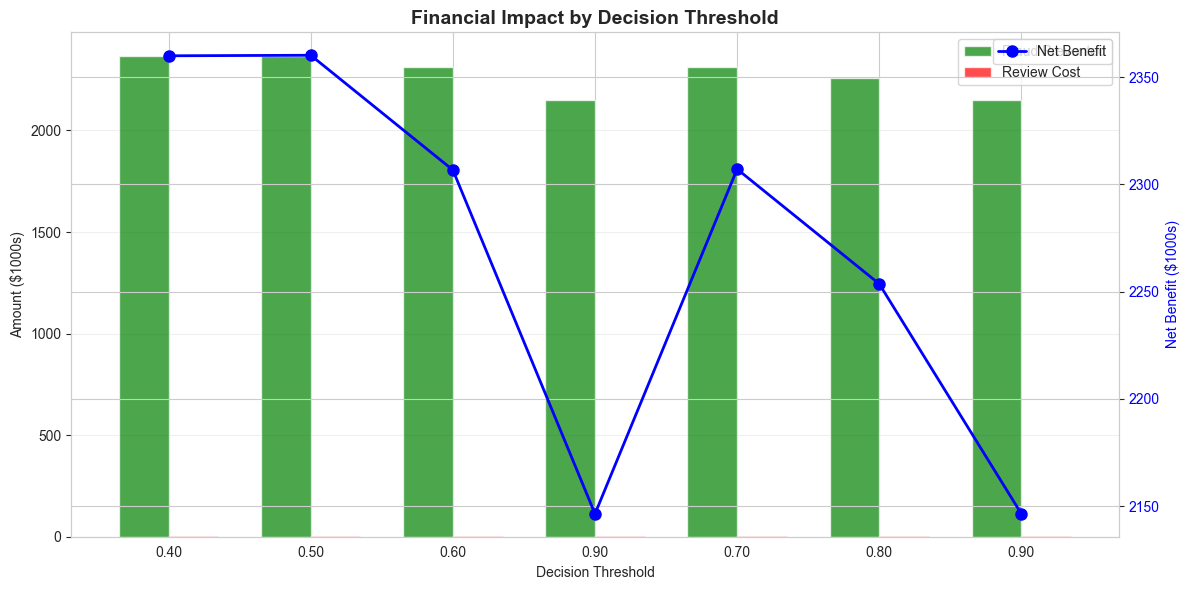


Financial impact chart saved to: ../docs/financial_impact.png


In [5]:

# ==============================================================================
# PART 3: BUSINESS IMPACT CALCULATION
# ==============================================================================

print("\nPART 3: Calculating business impact...")
print("-" * 80)

# Define business costs
COST_PER_MANUAL_REVIEW = 35  # dollars
AVG_FRAUD_CLAIM_AMOUNT = inpatient[inpatient['is_fraud_80']==1]['CLM_PMT_AMT'].mean()
AVG_LEGIT_CLAIM_AMOUNT = inpatient[inpatient['is_fraud_80']==0]['CLM_PMT_AMT'].mean()

print(f"\nBusiness parameters:")
print(f"  Manual review cost: ${COST_PER_MANUAL_REVIEW}")
print(f"  Average fraud claim: ${AVG_FRAUD_CLAIM_AMOUNT:,.2f}")
print(f"  Average legit claim: ${AVG_LEGIT_CLAIM_AMOUNT:,.2f}")

# Calculate financial impact for different thresholds
for threshold in [0.5, optimal_threshold, 0.7, 0.8]:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate costs and savings
    # Cost: Manual review of flagged claims
    review_cost = (tp + fp) * COST_PER_MANUAL_REVIEW
    
    # Savings: Fraud prevented (true positives)
    fraud_prevented = tp * AVG_FRAUD_CLAIM_AMOUNT
    
    # Loss: Fraud that slipped through (false negatives)
    fraud_missed = fn * AVG_FRAUD_CLAIM_AMOUNT
    
    # Net benefit
    net_benefit = fraud_prevented - review_cost
    
    # ROI calculation
    roi = ((fraud_prevented - review_cost) / review_cost) * 100 if review_cost > 0 else 0
    
    print(f"\nThreshold: {threshold:.2f}")
    print(f"  Fraud caught: {tp:,} claims (${fraud_prevented:,.0f} prevented)")
    print(f"  Fraud missed: {fn:,} claims (${fraud_missed:,.0f} loss)")
    print(f"  False alarms: {fp:,} claims")
    print(f"  Review cost: ${review_cost:,.0f}")
    print(f"  Net benefit: ${net_benefit:,.0f}")
    print(f"  ROI: {roi:.1f}%")

# Visualize financial impact
thresholds_for_plot = [0.4, 0.5, 0.6, optimal_threshold, 0.7, 0.8, 0.9]
financial_results = []

for threshold in thresholds_for_plot:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    review_cost = (tp + fp) * COST_PER_MANUAL_REVIEW
    fraud_prevented = tp * AVG_FRAUD_CLAIM_AMOUNT
    net_benefit = fraud_prevented - review_cost
    
    financial_results.append({
        'threshold': threshold,
        'fraud_prevented': fraud_prevented,
        'review_cost': review_cost,
        'net_benefit': net_benefit,
        'tp': tp,
        'fp': fp
    })

financial_df = pd.DataFrame(financial_results)

# Plot financial impact
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(financial_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], financial_df['fraud_prevented']/1000, 
               width, label='Fraud Prevented', color='green', alpha=0.7)
bars2 = ax.bar([i + width/2 for i in x], financial_df['review_cost']/1000, 
               width, label='Review Cost', color='red', alpha=0.7)

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Amount ($1000s)')
ax.set_title('Financial Impact by Decision Threshold', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in financial_df['threshold']])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add net benefit line
ax2 = ax.twinx()
ax2.plot(x, financial_df['net_benefit']/1000, 'b-o', linewidth=2, 
         markersize=8, label='Net Benefit')
ax2.set_ylabel('Net Benefit ($1000s)', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'financial_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFinancial impact chart saved to: ../docs/financial_impact.png")


PART 4: Creating claim prioritization system...
--------------------------------------------------------------------------------

Risk Tier Summary:
           claim_count  actual_fraud_count  fraud_rate  total_claim_amount  \
risk_tier                                                                    
Very Low         13206                   2       0.000         120402000.0   
Low                 17                   0       0.000            658000.0   
Medium              19                   1       0.053            961000.0   
High                16                   3       0.188            687000.0   
Critical            97                  40       0.412           5233000.0   

           avg_fraud_probability  
risk_tier                         
Very Low                   0.001  
Low                        0.394  
Medium                     0.608  
High                       0.812  
Critical                   0.978  


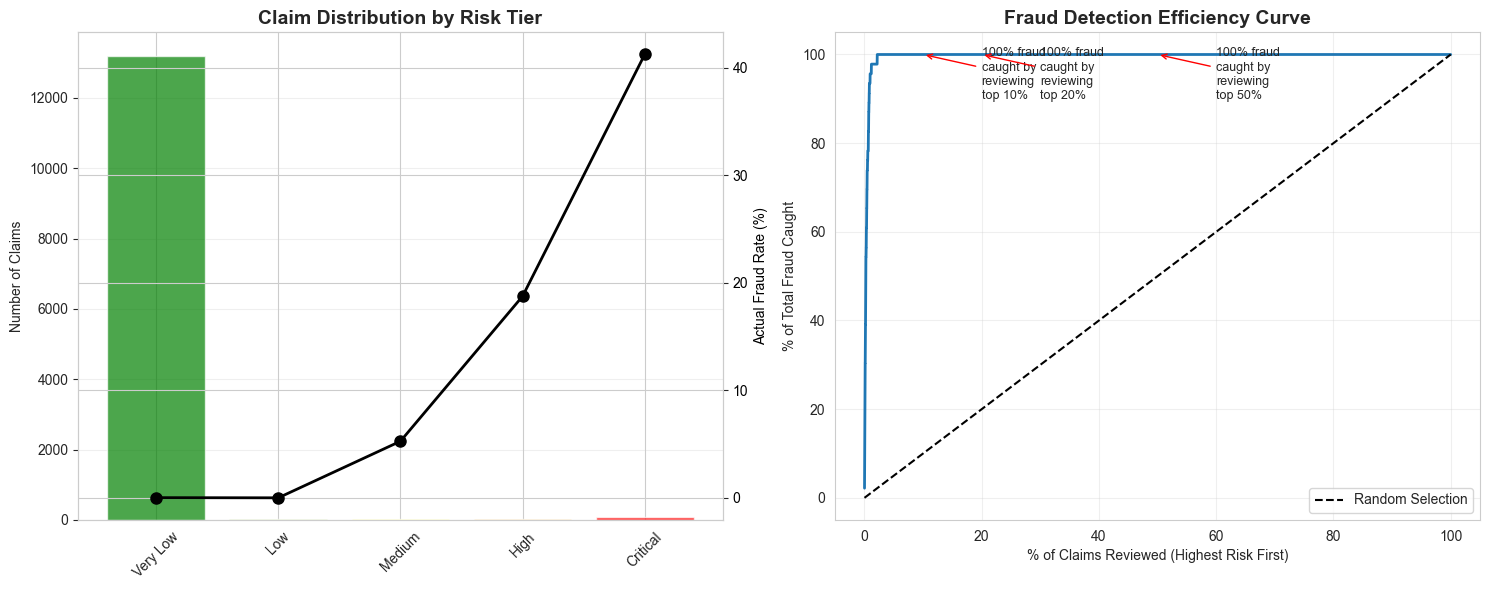


Claim prioritization chart saved to: ../docs/claim_prioritization.png

Efficiency Analysis:
If fraud analysts can only review X% of claims, prioritizing by model score:
  Review top  5% of claims -> Catch 46/46 fraud (100.0%)
  Review top 10% of claims -> Catch 46/46 fraud (100.0%)
  Review top 20% of claims -> Catch 46/46 fraud (100.0%)
  Review top 50% of claims -> Catch 46/46 fraud (100.0%)


In [6]:

# ==============================================================================
# PART 4: CLAIM PRIORITIZATION
# ==============================================================================

print("\nPART 4: Creating claim prioritization system...")
print("-" * 80)

# Create risk tiers based on predicted fraud probability
# This helps fraud analysts prioritize which claims to review first

# Get claim amounts from test set
test_indices = X_test.index
test_claim_amounts = inpatient.loc[test_indices, 'CLM_PMT_AMT']

# Create prioritization dataframe
priority_df = pd.DataFrame({
    'claim_index': test_indices,
    'fraud_probability': y_pred_proba,
    'actual_fraud': y_test.values,
    'claim_amount': test_claim_amounts.values
})

# Define risk tiers
priority_df['risk_tier'] = pd.cut(
    priority_df['fraud_probability'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Critical']
)

# Calculate expected fraud amount by tier
tier_summary = priority_df.groupby('risk_tier').agg({
    'claim_index': 'count',
    'actual_fraud': ['sum', 'mean'],
    'claim_amount': 'sum',
    'fraud_probability': 'mean'
}).round(3)

tier_summary.columns = ['claim_count', 'actual_fraud_count', 'fraud_rate', 
                        'total_claim_amount', 'avg_fraud_probability']

print("\nRisk Tier Summary:")
print(tier_summary)

# Visualize risk tiers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Claim distribution by risk tier
tier_counts = priority_df['risk_tier'].value_counts().sort_index()
axes[0].bar(range(len(tier_counts)), tier_counts.values, 
           color=['green', 'yellowgreen', 'yellow', 'orange', 'red'], alpha=0.7)
axes[0].set_xticks(range(len(tier_counts)))
axes[0].set_xticklabels(tier_counts.index, rotation=45)
axes[0].set_ylabel('Number of Claims')
axes[0].set_title('Claim Distribution by Risk Tier', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add fraud rate on secondary axis
ax_twin = axes[0].twinx()
fraud_rates = priority_df.groupby('risk_tier')['actual_fraud'].mean().sort_index() * 100
ax_twin.plot(range(len(fraud_rates)), fraud_rates.values, 'ko-', linewidth=2, markersize=8)
ax_twin.set_ylabel('Actual Fraud Rate (%)', color='black')
ax_twin.tick_params(axis='y', labelcolor='black')

# Plot 2: Cumulative fraud caught by reviewing top N% claims
priority_df_sorted = priority_df.sort_values('fraud_probability', ascending=False)
priority_df_sorted['cumulative_fraud_pct'] = (
    priority_df_sorted['actual_fraud'].cumsum() / priority_df_sorted['actual_fraud'].sum() * 100
)
priority_df_sorted['pct_claims_reviewed'] = (
    np.arange(1, len(priority_df_sorted) + 1) / len(priority_df_sorted) * 100
)

axes[1].plot(priority_df_sorted['pct_claims_reviewed'], 
            priority_df_sorted['cumulative_fraud_pct'], linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', label='Random Selection')
axes[1].set_xlabel('% of Claims Reviewed (Highest Risk First)')
axes[1].set_ylabel('% of Total Fraud Caught')
axes[1].set_title('Fraud Detection Efficiency Curve', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Annotate key points
for pct in [10, 20, 50]:
    fraud_caught = priority_df_sorted[
        priority_df_sorted['pct_claims_reviewed'] <= pct
    ]['cumulative_fraud_pct'].iloc[-1]
    axes[1].annotate(f'{fraud_caught:.0f}% fraud\ncaught by\nreviewing\ntop {pct}%',
                    xy=(pct, fraud_caught),
                    xytext=(pct+10, fraud_caught-10),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'claim_prioritization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClaim prioritization chart saved to: ../docs/claim_prioritization.png")

# Show how much fraud can be caught with limited resources
print("\nEfficiency Analysis:")
print("If fraud analysts can only review X% of claims, prioritizing by model score:")
for pct in [5, 10, 20, 50]:
    fraud_caught = priority_df_sorted[
        priority_df_sorted['pct_claims_reviewed'] <= pct
    ]['actual_fraud'].sum()
    total_fraud = priority_df_sorted['actual_fraud'].sum()
    print(f"  Review top {pct:2}% of claims -> Catch {fraud_caught}/{total_fraud} fraud ({fraud_caught/total_fraud*100:.1f}%)")


In [8]:
# ==============================================================================
# PART 5: MODEL LIMITATIONS AND RECOMMENDATIONS
# ==============================================================================

print("\nPART 5: Model limitations and recommendations...")
print("-" * 80)

# Analyze where the model struggles
false_negatives = priority_df[
    (priority_df['actual_fraud'] == 1) & 
    (priority_df['fraud_probability'] < optimal_threshold)
]

false_positives = priority_df[
    (priority_df['actual_fraud'] == 0) & 
    (priority_df['fraud_probability'] >= optimal_threshold)
]

print(f"\nModel Limitations:")
print(f"  False Negatives: {len(false_negatives)} fraud cases missed")
print(f"    Average probability: {false_negatives['fraud_probability'].mean():.3f}")
print(f"    Average claim amount: ${false_negatives['claim_amount'].mean():,.2f}")
print(f"\n  False Positives: {len(false_positives)} legitimate claims flagged")
print(f"    Average probability: {false_positives['fraud_probability'].mean():.3f}")
print(f"    Average claim amount: ${false_positives['claim_amount'].mean():,.2f}")



PART 5: Model limitations and recommendations...
--------------------------------------------------------------------------------

Model Limitations:
  False Negatives: 6 fraud cases missed
    Average probability: 0.546
    Average claim amount: $47,000.00

  False Positives: 57 legitimate claims flagged
    Average probability: 0.972
    Average claim amount: $53,175.44


In [9]:

# ==============================================================================
# SUMMARY AND RECOMMENDATIONS
# ==============================================================================

print("\n" + "="*80)
print("MODEL EVALUATION COMPLETE")
print("="*80)

# Calculate best threshold metrics
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
tn_opt, fp_opt, fn_opt, tp_opt = cm_optimal.ravel()

review_cost_opt = (tp_opt + fp_opt) * COST_PER_MANUAL_REVIEW
fraud_prevented_opt = tp_opt * AVG_FRAUD_CLAIM_AMOUNT
net_benefit_opt = fraud_prevented_opt - review_cost_opt

print(f"""
RECOMMENDED DEPLOYMENT CONFIGURATION:
  Decision Threshold: {optimal_threshold:.2f}
  
EXPECTED PERFORMANCE:
  Fraud Detection Rate: {tp_opt/(tp_opt+fn_opt)*100:.1f}% (catch {tp_opt}/{tp_opt+fn_opt} fraud cases)
  False Alarm Rate: {fp_opt/(fp_opt+tn_opt)*100:.1f}% ({fp_opt:,} legitimate claims flagged)
  
FINANCIAL IMPACT (per {len(y_test):,} claims):
  Fraud Prevented: ${fraud_prevented_opt:,.0f}
  Review Cost: ${review_cost_opt:,.0f}
  Net Benefit: ${net_benefit_opt:,.0f}
  ROI: {((fraud_prevented_opt - review_cost_opt) / review_cost_opt * 100):.0f}%

PROJECTED ANNUAL IMPACT (scaling to full portfolio):
  If applied to 500,000 claims/year:
    Fraud prevented: ${fraud_prevented_opt * (500000/len(y_test)):,.0f}
    Net benefit: ${net_benefit_opt * (500000/len(y_test)):,.0f}

RECOMMENDATIONS:
  1. Deploy with {optimal_threshold:.2f} threshold for balanced performance
  2. Prioritize review of "High" and "Critical" risk tiers
  3. By reviewing top 20% of claims, catch {priority_df_sorted[priority_df_sorted['pct_claims_reviewed'] <= 20]['actual_fraud'].sum() / total_fraud * 100:.0f}% of fraud
  4. Train advanced models (XGBoost) to improve recall
  5. Implement SHAP explainability for transparency
  6. Set up feedback loop: confirmed fraud -> retrain model
""")

print("="*80)


MODEL EVALUATION COMPLETE

RECOMMENDED DEPLOYMENT CONFIGURATION:
  Decision Threshold: 0.90
  
EXPECTED PERFORMANCE:
  Fraud Detection Rate: 87.0% (catch 40/46 fraud cases)
  False Alarm Rate: 0.4% (57 legitimate claims flagged)
  
FINANCIAL IMPACT (per 13,355 claims):
  Fraud Prevented: $2,149,869
  Review Cost: $3,395
  Net Benefit: $2,146,474
  ROI: 63225%

PROJECTED ANNUAL IMPACT (scaling to full portfolio):
  If applied to 500,000 claims/year:
    Fraud prevented: $80,489,292
    Net benefit: $80,362,186

RECOMMENDATIONS:
  1. Deploy with 0.90 threshold for balanced performance
  2. Prioritize review of "High" and "Critical" risk tiers
  3. By reviewing top 20% of claims, catch 100% of fraud
  4. Train advanced models (XGBoost) to improve recall
  5. Implement SHAP explainability for transparency
  6. Set up feedback loop: confirmed fraud -> retrain model

